[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HonYaoZhi/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb)

# PyTorch Workflow
Resources:
* Book version of notebook - https://www.learnpytorch.io/01_pytorch_workflow/

In [ ]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.10.0+cpu'

PyTorch provides multiple building blocks to customize your own neural network:
https://docs.pytorch.org/docs/main/nn.html

## 1. Data (Preparing and Loading)

Data can be almost anything... in machine learning

* Excel spreadsheet
* Images of any kind
* Videos (YouTube has lots of data)
* Audio like songs or podcasts
* DNA
* Text

Machine learning is a game of two parts:

1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

To showcase this, let's create some known data using the linear regression formula.

We'll use a linear regression formula to make a straight line with known **parameters**.

In [ ]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
#   Capital letter represents a matrix/tensor, lower case represents a letter
X = torch.arange(start, end, step).unsqueeze(dim=1) # unsqueeze() adds extra dimension
y = weight * X + bias # linear regression formula

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

The whole premise of machine learning is to learn a representation of the input and how it maps to the output.

In [ ]:
len(X), len(y)

(50, 50)

## 2. Splitting data into training and test sets

One of the most important concepts in machine learning in general

Let's create a training and test set with our data.

In [ ]:
# Create a train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

**Common Data Splitting Method**:

Scikit Learn train_test_split that adds randomness in splitting data.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

**How might we better visualize our data?**

This is where the data explorer's motto comes in!

"Visualize, visualize, visualize!"

In [ ]:
# Use matplotlib to visualize the data
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  # Are there predictions?
  if predictions is not None:
    # Plot the predictions in red (predictions in test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

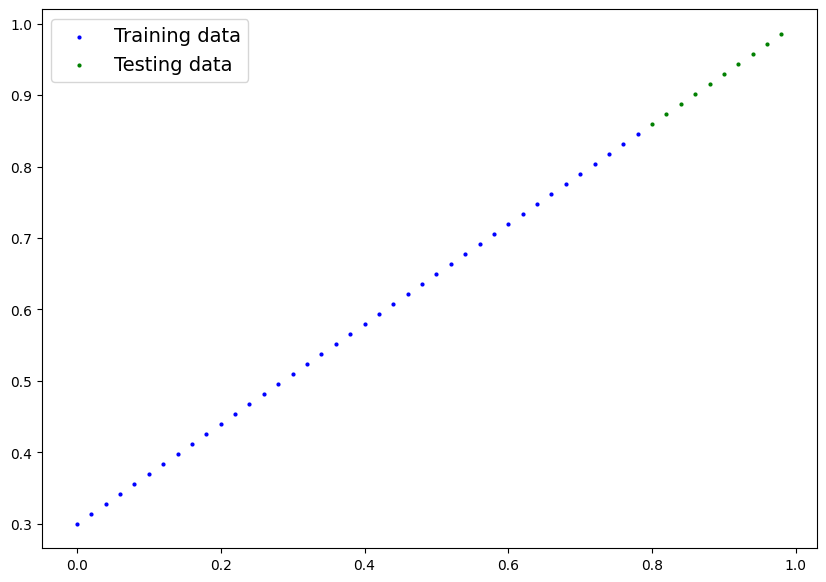

In [ ]:
plot_predictions()

## 3. Build Model
Python classes: https://realpython.com/python3-object-oriented-programming/

What our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight and bias values we use to create the data)

How does it do so?

Through two main algorithms:
* Gradient descent: -https://youtu.be/IHZwWFHWa-w
* Backpropagation

In [ ]:
from torch import nn

# Create linear regression model class
class LinearRegressionModel(nn.Module): # Almost everything in PyTorch inherits from nn.module
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.rand(1,   # <- start with a random weight and try to adjust it to the ideal weight
                                           requires_grad=True,  # <- can this parameter be updated via gradient descent?
                                           dtype=torch.float))  # <- PyTorch loves the datatype torch.float32
    self.bias = nn.Parameter(torch.rand(1,
                                         requires_grad=True,
                                         dtype=torch.float))

  # Forward defines the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data
    return self.weights * x + self.bias # This is the linear regression formula

### 3.1 PyTorch model building essentials

1. torch.nn - Contains all of the buildings for computational graphs (a neural network can be considered a computational graph)
2. torch.nn.Parameter - What parameters should our model try and learn, often a Pytorch layer from torch.nn will set these for us
3. torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward()
4. torch.optim - This where the optimizers in PyToch live, they will help with gradient descent
5. def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computations

More of these essential modules: https://pytorch-cn.com/tutorials/beginner/ptcheat.html

### 3.2 Checking the contents of our PyTorch model

Now we've created a model, let's see what's inside...

So we can check our model parameters or what's inside our model using `.parameters()`

In [ ]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [ ]:
# List named parameters (Return the dicionary of the parameters of the models)
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [ ]:
weight, bias

(0.7, 0.3)

### 3.3 Making prediction using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `x_test`.

When we pass data through our model, it's going to run it through the `forward()` method.

In [ ]:
# Make predictions with model using INFERENCE MODE
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

> The with statement in Python is context manager, used for resource management—it ensures that resources like files or network connections are automatically cleaned up (closed) even if an error occurs.


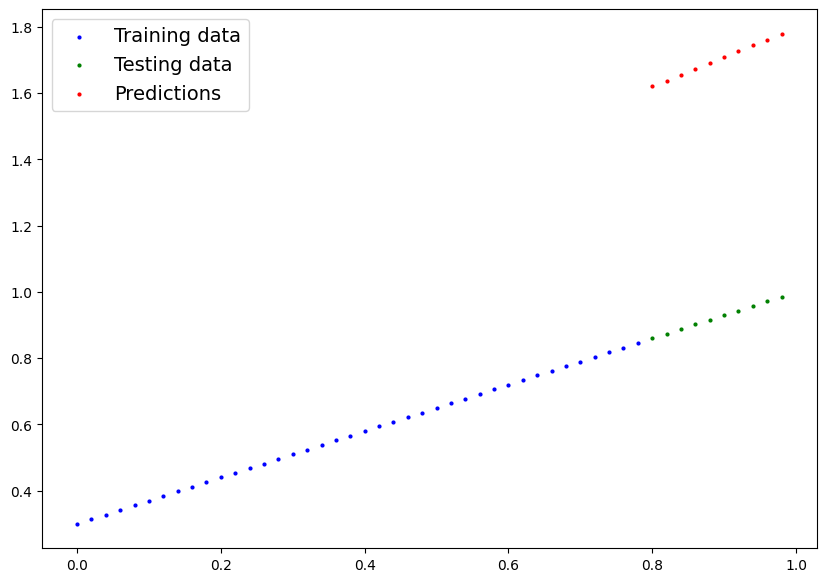

In [ ]:
# Plot predictions vs truth
plot_predictions(predictions=y_preds)

In [ ]:
# Make prediction without inference mode
y_preds = model_0(X_test)
y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]], grad_fn=<AddBackward0>)

What Inference Mode do?
* Turn off the gradient tracking
* Use when we are doing inference instead of training, that's why we no need to keep track of how we should update our model
* Faster prediction

Before Inference Mode appears, we use `no_grad()`:

* Do something similar with inference mode, but inference mode is preferred.

```
with torch.no_grad():
  y_preds = model_0(X_test)
```



## 4. Train model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters.

Or in other words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong your models predictions are is to use a **loss function**.

* Note: Loss function can also called cost function or criterion.

Things we need to train:
* Loss function
* **Optimizer**: Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias) to improve the loss function
https://docs.pytorch.org/docs/2.11/optim.html

And specifically for PyTorch, we need:
* A training loop
* A testing loop

In [ ]:
# Setup a loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Setup an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01) # lr = learning rate, a hyperparameter

**Q**: Which loss function and optimizer should I use?
**A**: This will be problem specific. But with experience, you'll get an idea of what works and what doesn't with your particular problem set.

For example, for a regression problem, a loss function of `nn.L1Loss()` and an optimizer like `torch.optim.SGD()` will suffice.

But for a classification problem like classifying whether a photo is of a dog or a cat, you'll likely want to use a loss function of `nn.BCELoss()` (binary cross entropy loss)

## 4.1 Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:

0. Loop through the data
1. Forward pass / **Forward propagation** (this involves data moving through our model's `forward()` functions) to make predictions on data
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward / **Backward propagation** - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss
5. Optimizer step / **Gradient descent** - use the optimizer to adjust our model's parameters to try and improve the loss.

`torch.autograd`
Learning rate scheduling

### 4.2 Simple version of Training Loop

In [ ]:
# An epoch is one loop through the data... (this is a hyperparameter because we've set it oursleves)
epochs = 10

# Training
# 0. Loop through the data
for epoch in range(epochs):
  # Set the model to training mode
  model_0.train() # TRAINING mode in PyTorch sets all parameters that require gradients to requir_grad

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)
  print(f"Loss: {loss}")

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Perform backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  # 5. Optimizer step (perform gradient descent)
  optimizer.step() # By default how the optimizer changes will accumulate through the loop so we have to zero them above in step 3 for the next iteration of the loop

  # Testing
  model_0.eval() # EVALUATION mode, turns off different settings in the model not needed for evaluation/testing (dropout/batch norm layers)

Loss: 0.1100396141409874
Loss: 0.09851861745119095
Loss: 0.0869976356625557
Loss: 0.07547664642333984
Loss: 0.06395565718412399
Loss: 0.05243467539548874
Loss: 0.04091368243098259
Loss: 0.029392695054411888
Loss: 0.017871711403131485
Loss: 0.010616960003972054


In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6526])), ('bias', tensor([0.3215]))])

In [ ]:
weight, bias

(0.7, 0.3)

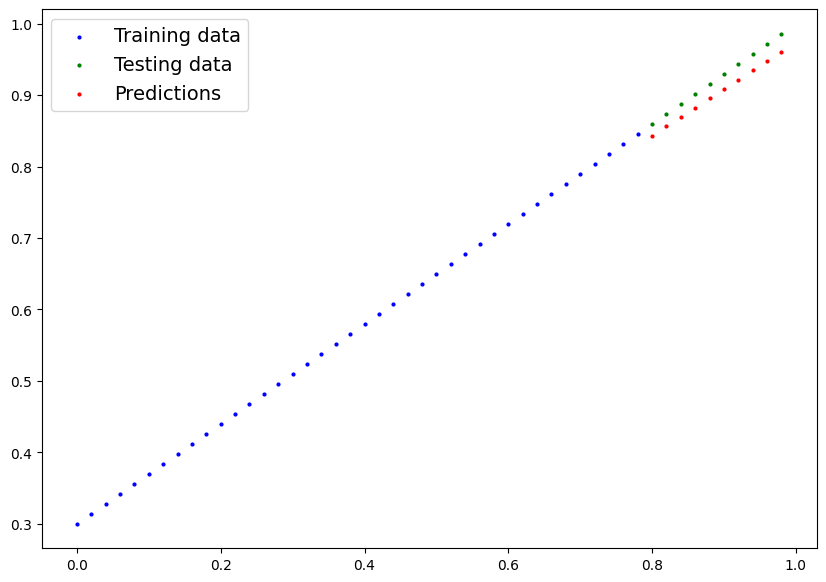

In [ ]:
# Trying to make new prediction
with torch.inference_mode():
  y_pred_new = model_0(X_test)

plot_predictions(predictions=y_pred_new)

### 4.3 Integrate Training Loop with Testing Loop


In [ ]:
# An epoch is one loop through the data... (this is a hyperparameter because we've set it oursleves)
epochs = 200

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []

# Training
# 0. Loop through the data
for epoch in range(epochs):
  # Set the model to training mode
  model_0.train() # TRAINING mode in PyTorch sets all parameters that require gradients to requir_grad

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Perform backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  # 5. Optimizer step (perform gradient descent)
  optimizer.step() # By default how the optimizer changes will accumulate through the loop so we have to zero them above in step 3 for the next iteration of the loop

  # Testing
  model_0.eval() # EVALUATION mode, turns off different settings in the model not needed for evaluation/testing (dropout/batch norm layers)

  with torch.inference_mode(): # turns off gradient tracking & a couple more things behind the scenes
    # 1. Do the forward pass
    test_pred = model_0(X_test)

    # 2. Calculate the loss
    test_loss = loss_fn(test_pred, y_test)

  #Print out what's happening
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
    print(model_0.state_dict())#

Epoch: 0 | Loss: 0.6860889196395874 | Test loss: 0.7637526988983154
OrderedDict({'weights': tensor([0.8784]), 'bias': tensor([0.9050])})
Epoch: 10 | Loss: 0.5708791017532349 | Test loss: 0.6290428042411804
OrderedDict({'weights': tensor([0.8394]), 'bias': tensor([0.8050])})
Epoch: 20 | Loss: 0.45566922426223755 | Test loss: 0.4943329691886902
OrderedDict({'weights': tensor([0.8004]), 'bias': tensor([0.7050])})
Epoch: 30 | Loss: 0.34045934677124023 | Test loss: 0.35962313413619995
OrderedDict({'weights': tensor([0.7614]), 'bias': tensor([0.6050])})
Epoch: 40 | Loss: 0.2252494841814041 | Test loss: 0.2249133139848709
OrderedDict({'weights': tensor([0.7224]), 'bias': tensor([0.5050])})
Epoch: 50 | Loss: 0.1100396141409874 | Test loss: 0.09020347893238068
OrderedDict({'weights': tensor([0.6834]), 'bias': tensor([0.4050])})
Epoch: 60 | Loss: 0.009724985808134079 | Test loss: 0.020998019725084305
OrderedDict({'weights': tensor([0.6539]), 'bias': tensor([0.3200])})
Epoch: 70 | Loss: 0.0062167

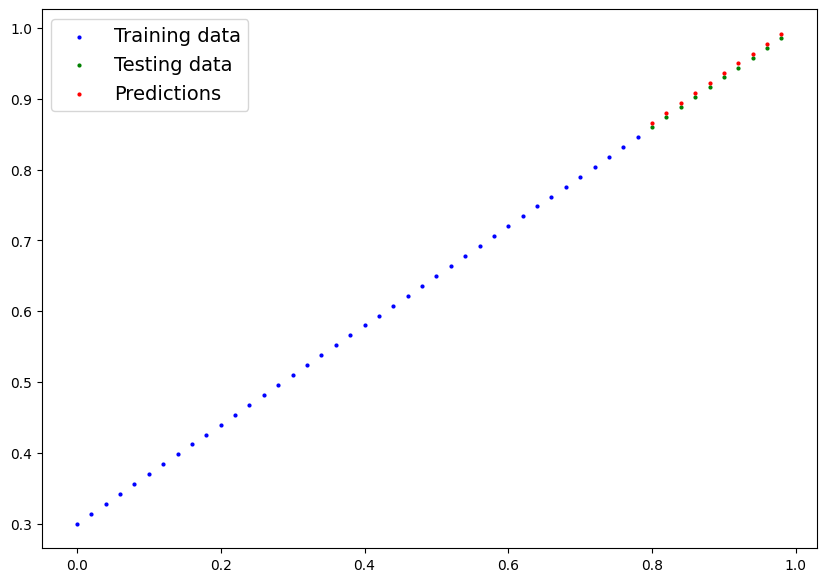

In [ ]:
# Trying to make new prediction
with torch.inference_mode():
  y_pred_new = model_0(X_test)

plot_predictions(predictions=y_pred_new)

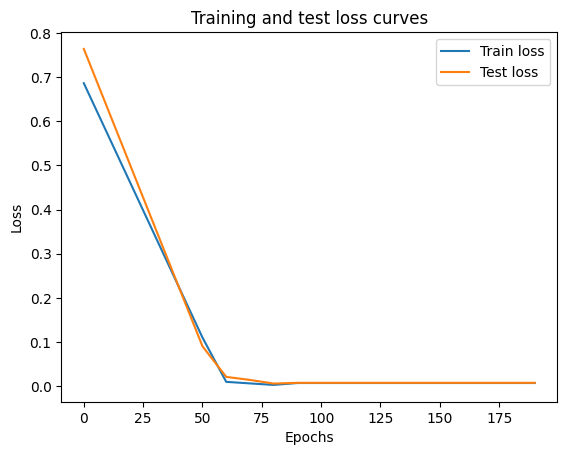

In [ ]:
import numpy as np

# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

**The model is converging**: The two curve match up together.

This line `np.array(torch.tensor(loss_values).numpy())` converts `loss_values` for plotting:

*   **`loss_values`**: A Python list of individual PyTorch tensor objects (the loss from each epoch).
*   **`torch.tensor(loss_values)`**: Consolidates this list into a single PyTorch tensor.
*   **`.numpy()`**: Converts the PyTorch tensor into a NumPy array, which is commonly required by plotting libraries like `matplotlib`.
*   **`np.array(...)`**: Ensures the final output is explicitly a NumPy array.

## 5. Saving a model in PyTorch

There are three main methods for saving and loading models in PyTorch

1. `torch.save()` - allows you to save a PyTorch object in Python's pickle format (Serialize)

2. `torch.load()` - allows you to load a saved PyTorch object (Deserialize)

3. `torch.nn.Module.load_state_dict()` - this allows to load a model's saved state dictionary (parameters)

PyTorch save and load code tutorial: https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

In [ ]:
# Saving PyTorch model
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True) # If exist won't throw error

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict (Can save the whole model too)
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [ ]:
!ls -1 models

01_pytorch_workflow_model_0.pth


## 6. Loading a PyTorch model

Since we saved our model's `state_dict()` rather the entire model, we'll create a new instance of our model class and load the saved `state_dict()` into that.

In [ ]:
loaded_model_0 = LinearRegressionModel()

# Currently is the random initialized parameters
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.3829])), ('bias', tensor([0.9593]))])

In [ ]:
# Update the new instance with the updated parameters
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6977])), ('bias', tensor([0.3080]))])

In [ ]:
# Make some predictions with our loaded model
loaded_model_0.eval()

with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8661],
        [0.8801],
        [0.8940],
        [0.9080],
        [0.9220],
        [0.9359],
        [0.9499],
        [0.9638],
        [0.9778],
        [0.9917]])

In [ ]:
# Compare loaded model preds with original model preds
model_0.eval()

with torch.inference_mode():
  original_model_preds = model_0(X_test)

original_model_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 7. Putting it all together

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

**Create device-agnostic code.**

This means if we 've got access to a GPU, our code will use it (for potentially faster computing).

If no GPU is available, the code will default to use CPU.

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


### 7.1 Data

In [ ]:
# Create some data using the linear regression formula for y = weight * X + bias
weight = 0.7
bias = 0.3

# Create range value
start = 0
end = 1
step = 0.02

# Create x and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
# Split data
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

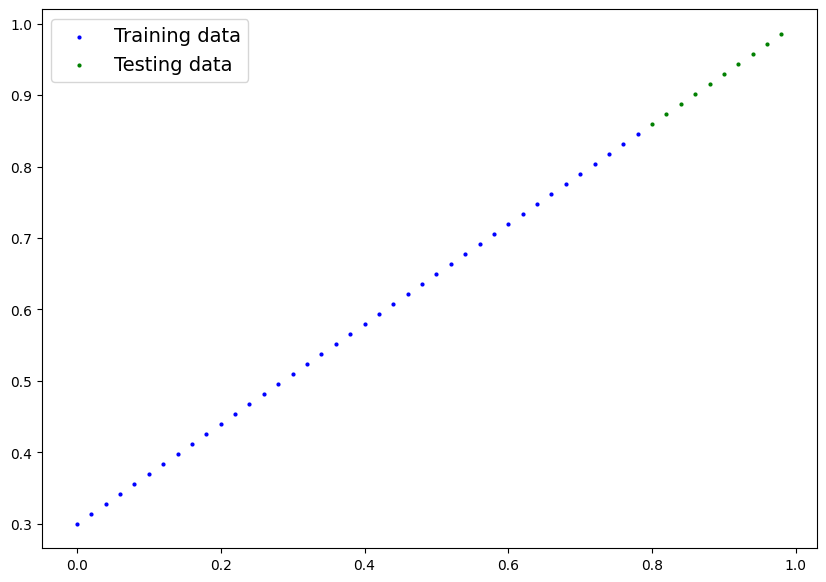

In [ ]:
# Plot the data
plot_predictions(X_train, y_train, X_test, y_test)

### 7.2 Buidling a PyTorch Linear Model

In [ ]:
# Create a linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # Use nn.Linear() for creating the model parameters / linear transform / probing layer / fully connected layer / dense layer
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1) # input and output of size 1

  def forward(self, x: torch.Tensor) -> torch.Tensor: # Should return torch.Tensor
    return self.linear_layer(x)

# Set the manual seed
torch.manual_seed(42)

# Create an instance of the model
model_1 = LinearRegressionModelV2()

model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
# Check the model current device
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
# Set the model to use target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

### 7.3 Training

In [ ]:
# Setup loss function
loss_fn = nn.L1Loss()

# Setup optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [ ]:
# Training loop
torch.manual_seed(42)

epochs = 200

# Put data on the target device (device agnostic code for data)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  # 1. Forward pass
  y_pred = model_1(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Perform backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  # 5. Optimizer step (perform gradient descent)
  optimizer.step()

  ## Testing
  model_1.eval()

  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred, y_test)

  # Print out what's happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Loss: 0.5551779866218567 | Test loss: 0.5739762187004089
Epoch: 10 | Loss: 0.4399680495262146 | Test loss: 0.4392663538455963
Epoch: 20 | Loss: 0.3247582018375397 | Test loss: 0.30455657839775085
Epoch: 30 | Loss: 0.20954827964305878 | Test loss: 0.16984674334526062
Epoch: 40 | Loss: 0.09433844685554504 | Test loss: 0.03513689711689949
Epoch: 50 | Loss: 0.023886386305093765 | Test loss: 0.04784906655550003
Epoch: 60 | Loss: 0.0199567973613739 | Test loss: 0.04580312222242355
Epoch: 70 | Loss: 0.016517987474799156 | Test loss: 0.0375305712223053
Epoch: 80 | Loss: 0.013089170679450035 | Test loss: 0.029944902285933495
Epoch: 90 | Loss: 0.009653178043663502 | Test loss: 0.02167237363755703
Epoch: 100 | Loss: 0.006215679459273815 | Test loss: 0.014086711220443249
Epoch: 110 | Loss: 0.002787243574857712 | Test loss: 0.005814164876937866
Epoch: 120 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 130 | Loss: 0.0012645035749301314 | Test loss: 0.01380180753767

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

### 7.4 Making and evaluating predictions

In [ ]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)

y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

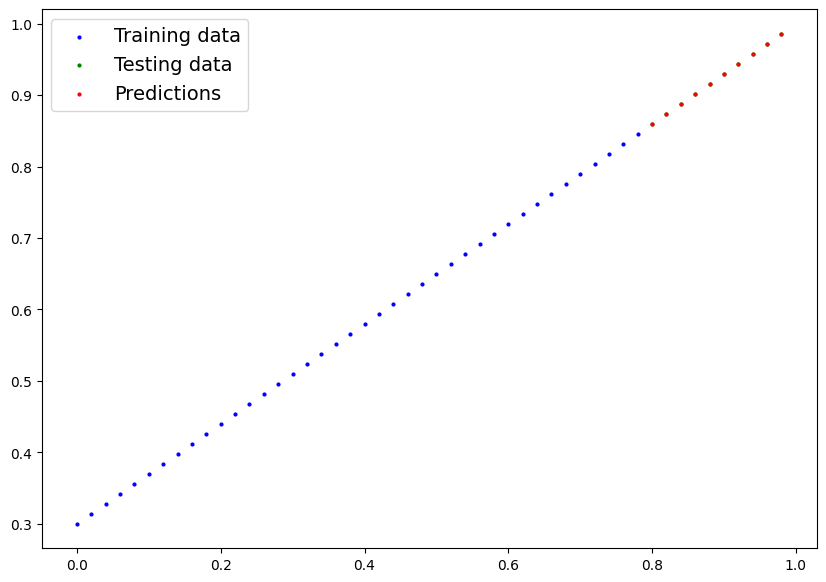

In [ ]:
# Plot predictions vs truth
plot_predictions(predictions=y_preds)

### 7.5 Saving and loading a trained model

In [ ]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict (Can save the whole model too)
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_1.pth


In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [ ]:
# Load a PyTorch
loaded_model_1 = LinearRegressionModelV2()
loaded_model_1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(loaded_model_1.parameters()).device

device(type='cpu')

In [ ]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [ ]:
# Evaluate loaded model
loaded_model_1.eval()

with torch.inference_mode():
  loaded_model_1_preds = loaded_model_1(X_test)

y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])